In [2]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord
import aeolus.calc

In [3]:
UM_THAI = iris.load('/data/cluster4/jj22956/thunderstruck_files/Hab1_UM_1_10.nc')
UM_THAI

/home/jj22956/.local/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


Upward Lw Flux On Levels And Bands (unknown),time,LW radiation bands,atmosphere_hybrid_height_coordinate,latitude,longitude
Shape,244,12,1,90,144
Dimension coordinates,,,,,
time,x,-,-,-,-
LW radiation bands,-,x,-,-,-
atmosphere_hybrid_height_coordinate,-,-,x,-,-
latitude,-,-,-,x,-
longitude,-,-,-,-,x
Auxiliary coordinates,,,,,
Fraction of orographic height,-,-,x,-,-
height_above_reference_ellipsoid,-,-,x,-,-


In [4]:
air_temperature = UM_THAI[12]
air_temperature

Air Temperature (K),time,--,latitude,longitude
Shape,244,42,90,144
Dimension coordinates,,,,
time,x,-,-,-
latitude,-,-,x,-
longitude,-,-,-,x
Auxiliary coordinates,,,,
Fraction of orographic height,-,x,-,-
atmosphere_hybrid_height_coordinate,-,x,-,-
height_above_reference_ellipsoid,-,x,-,-
model_level_number,-,x,-,-


In [5]:
air_pressure = UM_THAI[11]
print(air_pressure)

air_pressure / (Pa)                         (time: 244; -- : 42; latitude: 90; longitude: 144)
    Dimension coordinates:
        time                                     x         -             -              -
        latitude                                 -         -             x              -
        longitude                                -         -             -              x
    Auxiliary coordinates:
        Fraction of orographic height            -         x             -              -
        atmosphere_hybrid_height_coordinate      -         x             -              -
        height_above_reference_ellipsoid         -         x             -              -
        model_level_number                       -         x             -              -
    Cell methods:
        0                                   time: point
    Attributes:
        Conventions                         'CF-1.6'
        STASH                               m01s00i408
        packing_method 

In [6]:
# Temporal mean of air temperature and pressure

airtemp_t_mean = aeolus.calc.stats.time_mean(air_temperature)
airpressure_t_mean = aeolus.calc.stats.time_mean(air_pressure)
# print(airtemp_t_mean)
# print(airpressure_t_mean)

/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(


In [7]:
substellar_temp = airtemp_t_mean[:, 0, 0]
# print(substellar_temp)
temp_height = substellar_temp.coord('height_above_reference_ellipsoid').points
# print(temp_height)

In [8]:
temp_height = substellar_temp.coord('height_above_reference_ellipsoid').points
# print(temp_height)

In [9]:
substellar_pressure = airpressure_t_mean[:, 0, 0]
# substellar_pressure
pressure_height = airpressure_t_mean.coord('height_above_reference_ellipsoid').points
# pressure_height

In [16]:
temp_alt_points = [
    (
        temp_height,
        np.linspace(min(temp_height), max(temp_height), 1000),
    )
]
# scheme = iris.analysis.Linear()
# linear_column = substellar_temp.interpolate(temp_alt_points, scheme)

# print(temp_alt_points[0])


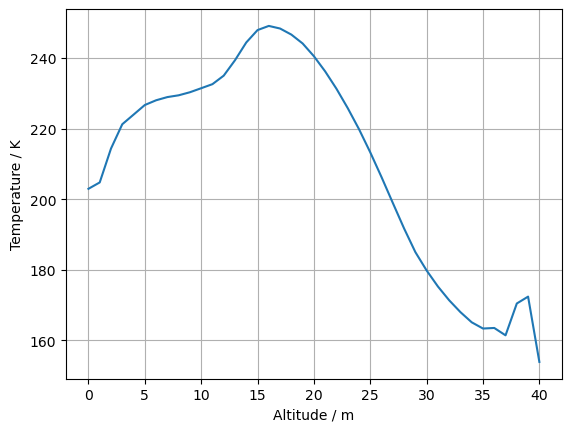

In [29]:
iplt.plot(substellar_temp)
plt.ylabel('Temperature / K')
plt.xlabel('Altitude / m')
plt.grid()

In [11]:
pressure_alt_points = [
    (
        pressure_height,
        np.linspace(min(pressure_height), max(pressure_height), 1000),
    )
]

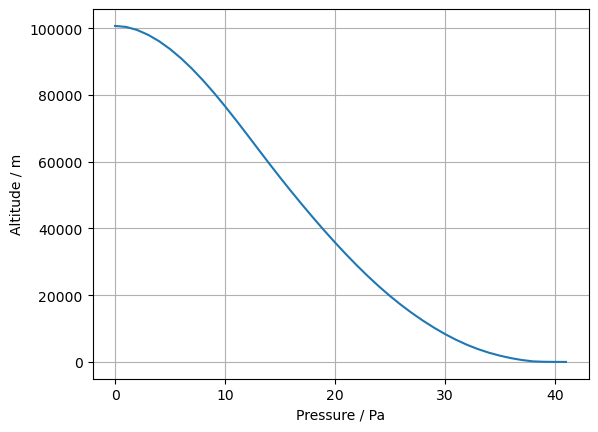

In [21]:
iplt.plot(substellar_pressure)
plt.xlabel('Pressure / Pa')
plt.ylabel('Altitude / m')
plt.grid()

ValueError: setting an array element with a sequence.

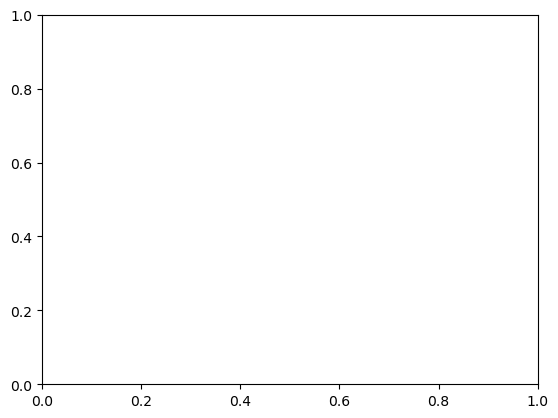

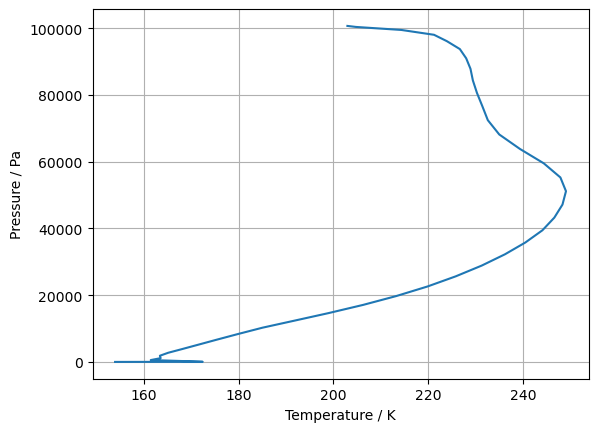

In [15]:
iplt.plot(substellar_temp, substellar_pressure)
plt.xlabel('Temperature / K')
plt.ylabel('Pressure / Pa')
plt.grid()
# plt.ylim(0, 5000)